In [ ]:
# ======================
# DOWNLOAD DATASET USING KAGGLEHUB
# ======================
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

# Construct dataset directory
DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)


Using Colab cache for faster access to the 'cattle-breeds-dataset' dataset.
Dataset downloaded to: /kaggle/input/cattle-breeds-dataset
Using data from: /kaggle/input/cattle-breeds-dataset/Cattle Breeds


Using Colab cache for faster access to the 'cattle-breeds-dataset' dataset.
Dataset downloaded to: /kaggle/input/cattle-breeds-dataset
Using data from: /kaggle/input/cattle-breeds-dataset/Cattle Breeds
Using device: cuda
Classes: ['Ayrshire cattle', 'Brown Swiss cattle', 'Holstein Friesian cattle', 'Jersey cattle', 'Red Dane cattle']
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 60.3MB/s]


Epoch 01 | Train Acc = 60.83% | Val Acc = 78.99%
Epoch 02 | Train Acc = 72.95% | Val Acc = 83.19%
Epoch 03 | Train Acc = 76.79% | Val Acc = 78.99%
Epoch 04 | Train Acc = 80.21% | Val Acc = 84.87%
Epoch 05 | Train Acc = 83.42% | Val Acc = 91.60%
Epoch 06 | Train Acc = 87.15% | Val Acc = 92.44%
Epoch 07 | Train Acc = 86.84% | Val Acc = 95.80%
Epoch 08 | Train Acc = 91.81% | Val Acc = 93.28%
Epoch 09 | Train Acc = 92.12% | Val Acc = 94.96%
Epoch 10 | Train Acc = 92.33% | Val Acc = 94.12%
Epoch 11 | Train Acc = 94.92% | Val Acc = 94.12%

⛔ Early stopping triggered at Epoch 11! Best Val Acc = 95.80%


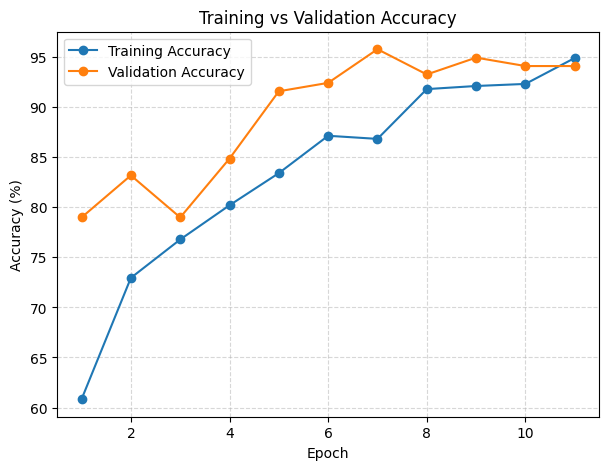

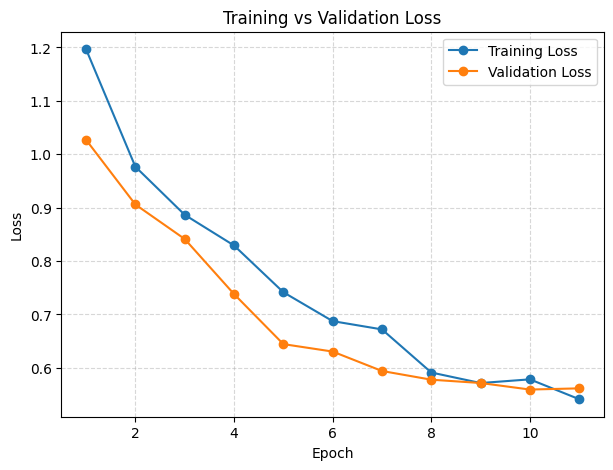


TEST REPORT:
                          precision    recall  f1-score   support

         Ayrshire cattle       0.92      0.92      0.92        26
      Brown Swiss cattle       0.95      0.84      0.89        25
Holstein Friesian cattle       0.86      0.92      0.89        26
           Jersey cattle       0.75      0.92      0.83        26
         Red Dane cattle       1.00      0.76      0.86        21

                accuracy                           0.88       124
               macro avg       0.90      0.87      0.88       124
            weighted avg       0.89      0.88      0.88       124



In [ ]:
# ============================================================
# DOWNLOAD DATASET USING KAGGLEHUB
# ============================================================
import os
import kagglehub

path = kagglehub.dataset_download("anandkumarsahu09/cattle-breeds-dataset")
print("Dataset downloaded to:", path)

DATA_DIR = os.path.join(path, "Cattle Breeds")
print("Using data from:", DATA_DIR)

# ============================================================
# IMPORTS
# ============================================================
import random
import numpy as np
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# ============================================================
# LOAD DATASET
# ============================================================
base = datasets.ImageFolder(DATA_DIR, transform=test_transform)
class_names = base.classes
num_classes = len(class_names)
print("Classes:", class_names)

# ============================================================
# SPLIT DATASET
# ============================================================
def stratified_split(dataset):
    rng = np.random.default_rng(42)
    per_class = defaultdict(list)

    for i, (_, label) in enumerate(dataset.samples):
        per_class[label].append(i)

    train_idx, val_idx, test_idx = [], [], []
    for _, idxs in per_class.items():
        idxs = np.array(idxs)
        rng.shuffle(idxs)
        n = len(idxs)
        t = int(0.8 * n)
        v = int(0.1 * n)
        train_idx.extend(idxs[:t])
        val_idx.extend(idxs[t:t + v])
        test_idx.extend(idxs[t + v:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(base)

class SubsetWithTransform(Dataset):
    def __init__(self, base, idxs, transform):
        self.base = base
        self.idxs = idxs
        self.transform = transform

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        path, label = self.base.samples[self.idxs[i]]
        img = self.base.loader(path)
        return self.transform(img), label

train_ds = SubsetWithTransform(base, train_idx, train_transform)
val_ds   = SubsetWithTransform(base, val_idx, test_transform)
test_ds  = SubsetWithTransform(base, test_idx, test_transform)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)

# ============================================================
# MODEL — ENHANCED MOBILENETV2
# ============================================================
class MobileNetEnhanced(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

        for p in base.features[:10].parameters():
            p.requires_grad = False

        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        in_dim = base.classifier[1].in_features

        self.classifier = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).view(x.size(0), -1)
        return self.classifier(x)

model = MobileNetEnhanced(num_classes).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# ============================================================
# TRAINING WITH EARLY STOPPING
# ============================================================
best_val_acc = 0
patience = 4
wait = 0

train_acc_hist = []
val_acc_hist = []
train_loss_hist = []
val_loss_hist = []

def train(model, epochs=25):
    global best_val_acc, wait

    for ep in range(1, epochs + 1):
        model.train()
        total, correct, running_loss = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        v_correct, v_total, v_loss = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                v_loss += criterion(out, y).item()
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += y.size(0)

        val_acc = 100 * v_correct / v_total
        val_loss = v_loss / len(val_loader)
        scheduler.step()

        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)

        print(f"Epoch {ep:02d} | Train Acc = {train_acc:.2f}% | Val Acc = {val_acc:.2f}%")

        # ↳ EARLY STOPPING
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            wait = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            wait += 1
            if wait >= patience:
                print(f"\n⛔ Early stopping triggered at Epoch {ep}! Best Val Acc = {best_val_acc:.2f}%")
                model.load_state_dict(torch.load("best_model.pth"))
                return model

    model.load_state_dict(torch.load("best_model.pth"))
    return model

# ============================================================
# TRAIN NOW
# ============================================================
model = train(model, 25)

# ============================================================
# TRAIN VS VAL — ACCURACY & LOSS GRAPHS
# ============================================================
epochs = range(1, len(train_acc_hist) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_acc_hist, marker='o', label='Training Accuracy')
plt.plot(epochs, val_acc_hist, marker='o', label='Validation Accuracy')
plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(epochs, train_loss_hist, marker='o', label='Training Loss')
plt.plot(epochs, val_loss_hist, marker='o', label='Validation Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(); plt.show()

# ============================================================
# FINAL TEST RESULTS
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        all_preds.extend(model(x).argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

print("\nTEST REPORT:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Saving rd.jpeg to rd.jpeg
Image: rd.jpeg

Predicted Breed: Red Dane cattle
Confidence: 0.861458420753479


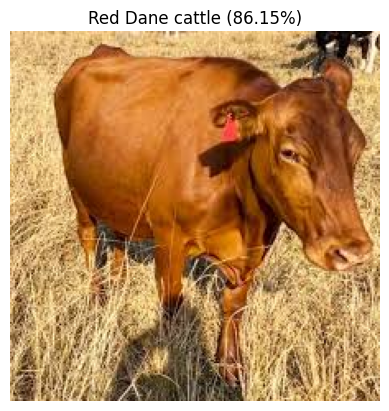

In [ ]:
# ============================
# IMAGE PREDICTION (UPLOAD FILE)
# ============================

from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt   # <-- ADD THIS

uploaded = files.upload()  # Choose an image

for filename in uploaded.keys():
    img_path = filename
    print("Image:", img_path)

    # Load the image
    img = Image.open(img_path).convert("RGB")

    # Apply same preprocess as test dataset
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485,0.456,0.406],
            [0.229,0.224,0.225],
        ),
    ])

    x = tfm(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        out = model(x)
        prob = torch.softmax(out, dim=1)[0]
        pred_idx = prob.argmax().item()

    print("\nPredicted Breed:", class_names[pred_idx])
    print("Confidence:", float(prob[pred_idx]))

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_names[pred_idx]} ({prob[pred_idx]*100:.2f}%)")
    plt.show()
